# Pennsylvania Severe Weather Atlas
## Notebook 01 — Project Setup and Data Inventory

### Research question
How do reported tornadoes, large hail, and damaging thunderstorm winds vary across Pennsylvania by location and season?

We will examine statewide patterns and take a closer look at the Lehigh Valley. We will define our study years and local counties during the data audit.

### Notebook goals
1. Verify the Python environment and analysis libraries.
2. Establish project paths and a data-source registry.
3. Review NOAA Storm Events documentation and inspect our first dataset.

### Imports and environment check
The kernel is the Python process that executes notebook code.

The next cell imports our tools and displays the interpreter path and package versions. This helps confirm that the notebook uses the environment we just created.

**Predict:** Which project folder should appear in the interpreter path?


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import requests

print("Python:", sys.version.split()[0])
print("Interpreter:", sys.executable)
print("Virtual environment:", sys.prefix != sys.base_prefix)

package_versions = pd.DataFrame({
    "Package": ["NumPy", "pandas", "Matplotlib", "seaborn", "requests"],
    "Version": [
        np.__version__,
        pd.__version__,
        matplotlib.__version__,
        sns.__version__,
        requests.__version__,
    ],
})

package_versions

Python: 3.13.5
Interpreter: c:\Users\rcolo\OneDrive\Desktop\Pennsylvania-Severe-Weather-Atlas\.venv\Scripts\python.exe
Virtual environment: True


,Package,Version
0,NumPy,2.5.3
1,pandas,3.0.5
2,Matplotlib,3.11.2
3,seaborn,0.13.2
4,requests,2.34.2


## Project paths

The project root is the main folder containing our notebooks, data, and reports.

We build paths from this root so our work consistently uses the correct folders. Raw data holds original source files; processed data holds cleaned versions prepared for analysis.

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_PATHS = {
    "raw_noaa": PROJECT_ROOT / "data" / "raw" / "noaa_storm_events",
    "processed": PROJECT_ROOT / "data" / "processed",
    "figures": PROJECT_ROOT / "reports" / "figures",
    "tables": PROJECT_ROOT / "reports" / "tables",
}

print("Project root:", PROJECT_ROOT)

path_check = pd.DataFrame([
    {"Folder": name, "Exists": path.is_dir()}
    for name, path in PROJECT_PATHS.items()
])

path_check

Project root: c:\Users\rcolo\OneDrive\Desktop\Pennsylvania-Severe-Weather-Atlas


,Folder,Exists
0,raw_noaa,True
1,processed,True
2,figures,True
3,tables,True


### Project path check — results

The project root correctly resolves to `Pennsylvania-Severe-Weather-Atlas`.

All four checked folders exist:
- `raw_noaa`
- `processed`
- `figures`
- `tables`

These paths identify where we will store original data, cleaned datasets, charts, and tables.

## Data-source registry

A source registry records where our data comes from and how we intend to use it. This helps other people trace and reproduce our work.

We will create our first entry for NOAA NCEI's Storm Events Database, which we plan to use to study reported tornadoes, hail, and thunderstorm winds in Pennsylvania.

The next cell saves the registry to `reports/tables/data_source_registry.csv`.

Using `index=False` keeps pandas row numbers out of the saved CSV.

In [3]:
source_registry = pd.DataFrame([{
    "source_id": "noaa_storm_events",
    "source_name": "Storm Events Database",
    "provider": "NOAA National Centers for Environmental Information",
    "source_url": "https://www.ncei.noaa.gov/access/storm-events-database/",
    "planned_use": "Pennsylvania tornado, hail, and thunderstorm-wind analysis",
    "status": "Pending data audit",
}])

registry_path = PROJECT_PATHS["tables"] / "data_source_registry.csv"

source_registry.to_csv(registry_path, index=False)

print("Saved to:", registry_path)

source_registry[["source_id", "source_name", "status"]]

Saved to: c:\Users\rcolo\OneDrive\Desktop\Pennsylvania-Severe-Weather-Atlas\reports\tables\data_source_registry.csv


,source_id,source_name,status
0,noaa_storm_events,Storm Events Database,Pending data audit


### Data-source registry — results

The registry was saved to `reports/tables/data_source_registry.csv`.

It contains one entry: `noaa_storm_events`, identifying NOAA's Storm Events Database.

Its status is `Pending data audit`. We still need to examine the available files and their coverage before selecting our study years.

## Inventory of available NOAA files

Before choosing study years, we will inspect NOAA's download directory.

We will focus on the event-details files. Their filenames contain:
- `dYYYY`: the year of the weather records.
- `cYYYYMMDD`: the file-creation date.

The next cell builds an inventory of filenames, years, and creation dates, then displays the ten latest entries.

`raise_for_status()` stops execution if the server returns an HTTP error.

In [4]:
NOAA_DIRECTORY_URL = "https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/"

directory_response = requests.get(NOAA_DIRECTORY_URL, timeout=30)
directory_response.raise_for_status()

filename_pattern = (
    r"(StormEvents_details-ftp_v[\d.]+_d(\d{4})_c(\d{8})\.csv\.gz)"
)

file_inventory = pd.Series([directory_response.text]).str.extractall(
    filename_pattern
)
file_inventory.columns = ["filename", "data_year", "file_created"]
file_inventory = file_inventory.drop_duplicates().reset_index(drop=True)

if file_inventory.empty:
    raise ValueError("No matching NOAA event-details filenames were found.")

file_inventory["data_year"] = file_inventory["data_year"].astype(int)
file_inventory["file_created"] = pd.to_datetime(
    file_inventory["file_created"], format="%Y%m%d"
)

file_inventory = file_inventory.sort_values(
    ["data_year", "file_created"]
).reset_index(drop=True)

print("Details files found:", len(file_inventory))
print(
    "Years listed:",
    file_inventory["data_year"].min(),
    "to",
    file_inventory["data_year"].max(),
)

file_inventory.tail(10)

Details files found: 77
Years listed: 1950 to 2026


,filename,data_year,file_created
67,StormEvents_details-ftp_v1.0_d2017_c20260519.c...,2017,2026-05-19
68,StormEvents_details-ftp_v1.0_d2018_c20260323.c...,2018,2026-03-23
69,StormEvents_details-ftp_v1.0_d2019_c20260323.c...,2019,2026-03-23
70,StormEvents_details-ftp_v1.0_d2020_c20260323.c...,2020,2026-03-23
71,StormEvents_details-ftp_v1.0_d2021_c20260323.c...,2021,2026-03-23
72,StormEvents_details-ftp_v1.0_d2022_c20260625.c...,2022,2026-06-25
73,StormEvents_details-ftp_v1.0_d2023_c20260323.c...,2023,2026-03-23
74,StormEvents_details-ftp_v1.0_d2024_c20260728.c...,2024,2026-07-28
75,StormEvents_details-ftp_v1.0_d2025_c20260819.c...,2025,2026-08-19
76,StormEvents_details-ftp_v1.0_d2026_c20260910.c...,2026,2026-09-10


### NOAA file inventory — results

The directory scan identified 77 event-details files, with data-year labels ranging from 1950 to 2026.

The displayed 2017 file has a creation date of 2026-05-19. This illustrates the distinction between the year represented by the records and the creation date of that file version.

The inventory establishes which files are available. We will examine their contents before finalizing our study period.

## Inspecting the first annual dataset

We will download the latest listed version of the 2025 event-details file and preserve it in our raw-data folder.

The `.csv.gz` extension means the CSV is compressed with gzip. pandas can read this format directly.

We will inspect the number of rows and columns, then preview event dates, states, county or zone names, and event types.

This first inspection will help us understand the dataset before filtering for Pennsylvania.

In [5]:
AUDIT_YEAR = 2025

audit_file = (
    file_inventory.loc[file_inventory["data_year"].eq(AUDIT_YEAR)]
    .sort_values("file_created")
    .iloc[-1]
)

raw_file_path = PROJECT_PATHS["raw_noaa"] / audit_file["filename"]

if not raw_file_path.exists():
    file_response = requests.get(
        NOAA_DIRECTORY_URL + audit_file["filename"],
        timeout=60,
    )
    file_response.raise_for_status()
    raw_file_path.write_bytes(file_response.content)

events_audit = pd.read_csv(
    raw_file_path,
    compression="gzip",
    low_memory=False,
)

print("Raw file:", raw_file_path)
print("Rows:", f"{len(events_audit):,}")
print("Columns:", events_audit.shape[1])

events_audit[
    ["BEGIN_DATE_TIME", "STATE", "CZ_NAME", "EVENT_TYPE"]
].head()

Raw file: c:\Users\rcolo\OneDrive\Desktop\Pennsylvania-Severe-Weather-Atlas\data\raw\noaa_storm_events\StormEvents_details-ftp_v1.0_d2025_c20260819.csv.gz
Rows: 72,360
Columns: 51


,BEGIN_DATE_TIME,STATE,CZ_NAME,EVENT_TYPE
0,31-MAR-25 11:04:00,GEORGIA,CARROLL,Thunderstorm Wind
1,30-MAR-25 15:52:00,MICHIGAN,CASS,Tornado
2,05-JAN-25 18:00:00,VIRGINIA,SPOTSYLVANIA,Winter Storm
3,03-JAN-25 13:00:00,MARYLAND,CENTRAL AND SOUTHEAST HOWARD,Winter Weather
4,03-JAN-25 13:00:00,MARYLAND,CENTRAL AND SOUTHEAST MONTGOMERY,Winter Weather


### First dataset inspection — results

The 2025 event-details file loaded successfully with 72,360 rows and 51 columns. Its filename identifies a file-creation date of 2026-08-19.

The preview includes records from Georgia, Michigan, Virginia, and Maryland. It also includes several weather categories: Thunderstorm Wind, Tornado, Winter Storm, and Winter Weather.

We will now isolate Pennsylvania records and examine which event categories appear.

## Pennsylvania event inventory

We will select records where `STATE` equals `PENNSYLVANIA`, then count records by `EVENT_TYPE`.

- `.eq()` creates a True/False condition, and `.loc[]` selects matching rows.
- `.copy()` creates a separate working DataFrame for Pennsylvania.
- `.value_counts(dropna=False)` counts each event category while also showing missing labels, if any.

These totals describe reported event records in the selected file.

In [6]:
pa_events_audit = events_audit.loc[
    events_audit["STATE"].eq("PENNSYLVANIA")
].copy()

pa_type_counts = (
    pa_events_audit["EVENT_TYPE"]
    .value_counts(dropna=False)
    .rename_axis("event_type")
    .reset_index(name="record_count")
)

print("Pennsylvania records:", f"{len(pa_events_audit):,}")
print("Distinct event types:", pa_events_audit["EVENT_TYPE"].nunique())
print("Missing event types:", pa_events_audit["EVENT_TYPE"].isna().sum())

pa_type_counts

Pennsylvania records: 2,249
Distinct event types: 23
Missing event types: 0


,event_type,record_count
0,Thunderstorm Wind,1010
1,Flash Flood,417
2,Winter Weather,220
3,Hail,132
4,Dense Fog,58
5,Cold/Wind Chill,52
6,Flood,50
7,Excessive Heat,46
8,Winter Storm,43
9,Drought,36


### Pennsylvania event inventory — results

The 2025 file contains 2,249 Pennsylvania records across 23 event types, with no missing event-type labels.

Our three focus categories are:

| Event type | Records |
|---|---:|
| Thunderstorm Wind | 1,010 |
| Hail | 132 |
| Tornado | 23 |

Together, these categories account for 1,165 records—approximately 51.8% of the Pennsylvania records in this file.

Thunderstorm Wind is the most frequently recorded category. These counts describe database records; assessing severity requires additional information.

## Selecting the project’s focus events

We will keep records labeled `Thunderstorm Wind`, `Hail`, or `Tornado`.

`.isin()` checks whether each event type matches one of these three labels.

We will also examine `EVENT_ID` for missing values and repeated identifiers. This helps us audit the record counts before creating our first chart.

In [7]:
FOCUS_EVENT_TYPES = ["Thunderstorm Wind", "Hail", "Tornado"]

pa_focus_audit = pa_events_audit.loc[
    pa_events_audit["EVENT_TYPE"].isin(FOCUS_EVENT_TYPES)
].copy()

focus_type_counts = (
    pa_focus_audit["EVENT_TYPE"]
    .value_counts()
    .reindex(FOCUS_EVENT_TYPES, fill_value=0)
    .rename_axis("event_type")
    .reset_index(name="record_count")
)

print("Focus records:", f"{len(pa_focus_audit):,}")
print("Missing event IDs:", pa_focus_audit["EVENT_ID"].isna().sum())
print(
    "Repeated non-missing event IDs:",
    pa_focus_audit["EVENT_ID"].dropna().duplicated().sum(),
)

focus_type_counts

Focus records: 1,165
Missing event IDs: 0
Repeated non-missing event IDs: 0


,event_type,record_count
0,Thunderstorm Wind,1010
1,Hail,132
2,Tornado,23


### Focus-event identifier check — results

The selected subset contains 1,165 records:
- Thunderstorm Wind: 1,010
- Hail: 132
- Tornado: 23

There are no missing event IDs and no repeated event IDs within this subset.

These checks support proceeding with an initial comparison of reported record counts.

## First visual: reported records by event type

We will create a horizontal bar chart comparing our three focus categories.

Each bar starts at zero, and its length represents the number of reported event records. Exact count labels will make smaller categories easier to read.

The chart will include a source note and will be saved to `reports/figures`.

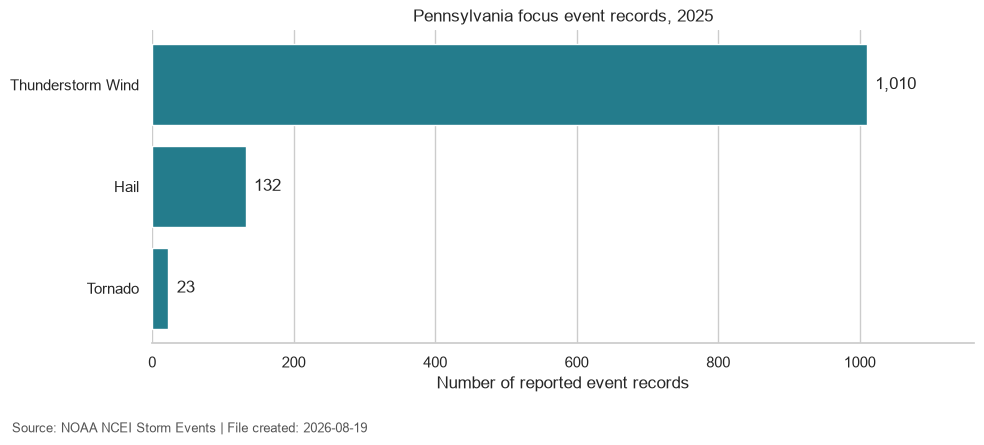

Saved chart: c:\Users\rcolo\OneDrive\Desktop\Pennsylvania-Severe-Weather-Atlas\reports\figures\pa_focus_event_counts_2025.png


In [8]:
sns.set_theme(style="whitegrid")

plot_data = focus_type_counts.sort_values("record_count")

fig, ax = plt.subplots(figsize=(10, 4.5))

bars = ax.barh(
    plot_data["event_type"],
    plot_data["record_count"],
    color="#247C8C",
)

ax.bar_label(
    bars,
    labels=[f"{value:,}" for value in plot_data["record_count"]],
    padding=6,
)

ax.set(
    title=f"Pennsylvania focus event records, {AUDIT_YEAR}",
    xlabel="Number of reported event records",
    ylabel="",
)
ax.set_xlim(0, plot_data["record_count"].max() * 1.15)
ax.grid(axis="y", visible=False)
sns.despine(ax=ax, left=True)

fig.text(
    0.02,
    0.02,
    f"Source: NOAA NCEI Storm Events | File created: {audit_file['file_created']:%Y-%m-%d}",
    fontsize=9,
    color="#555555",
)
fig.tight_layout(rect=[0, 0.07, 1, 1])

chart_path = PROJECT_PATHS["figures"] / f"pa_focus_event_counts_{AUDIT_YEAR}.png"
fig.savefig(chart_path, dpi=200, bbox_inches="tight")

plt.show()
print("Saved chart:", chart_path)

## Checking event dates

Converting text timestamps into datetime values lets us group records by calendar month.

We will convert `BEGIN_DATE_TIME`, count missing or unreadable dates, and check whether any successfully parsed dates fall outside 2025.

The format `%d-%b-%y %H:%M:%S` represents day, abbreviated month, two-digit year, hour, minute, and second.

With `errors="coerce"`, unreadable dates become `NaT`, pandas' missing-datetime value.

In [9]:
pa_focus_audit["begin_datetime"] = pd.to_datetime(
    pa_focus_audit["BEGIN_DATE_TIME"],
    format="%d-%b-%y %H:%M:%S",
    errors="coerce",
)

valid_begin_dates = pa_focus_audit["begin_datetime"].dropna()

print(
    "Missing or unreadable start dates:",
    pa_focus_audit["begin_datetime"].isna().sum(),
)
print("Earliest recorded start:", valid_begin_dates.min())
print("Latest recorded start:", valid_begin_dates.max())
print(
    "Records outside the audit year:",
    valid_begin_dates.dt.year.ne(AUDIT_YEAR).sum(),
)

pa_focus_audit[["BEGIN_DATE_TIME", "begin_datetime"]].head()


Missing or unreadable start dates: 0
Earliest recorded start: 2025-03-16 11:17:00
Latest recorded start: 2025-12-19 14:50:00
Records outside the audit year: 0


,BEGIN_DATE_TIME,begin_datetime
69,16-MAR-25 12:37:00,2025-03-16 12:37:00
114,16-MAR-25 11:52:00,2025-03-16 11:52:00
793,25-JUL-25 15:25:00,2025-07-25 15:25:00
794,25-JUL-25 15:30:00,2025-07-25 15:30:00
795,25-JUL-25 15:50:00,2025-07-25 15:50:00


### Event-date check — results

All 1,165 focus records have readable start dates, with no missing dates and no dates outside 2025.

- Earliest recorded start: March 16, 2025, at 11:17.
- Latest recorded start: December 19, 2025, at 14:50.

These are the observed date bounds of our filtered Pennsylvania subset containing Thunderstorm Wind, Hail, and Tornado records.

## Monthly distribution of focus events

We will count records by calendar month and event type.

- `pd.crosstab()` counts each month/event-type combination.
- `.reindex()` includes all twelve months, keeping zero-count months visible.

A zero means no matching records appear in this dataset for that combination.

We will also check that the monthly counts add back to the 1,165 records in our subset.

In [10]:
monthly_focus_counts = pd.crosstab(
    pa_focus_audit["begin_datetime"].dt.month,
    pa_focus_audit["EVENT_TYPE"],
).reindex(
    index=range(1, 13),
    columns=FOCUS_EVENT_TYPES,
    fill_value=0,
)

monthly_focus_counts.index = pd.Index(
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    name="month",
)
monthly_focus_counts.columns.name = None

monthly_focus_counts["total_records"] = monthly_focus_counts.sum(axis=1)

monthly_total = monthly_focus_counts["total_records"].sum()

print("Records in monthly table:", f"{monthly_total:,}")
print("Matches focus subset:", monthly_total == len(pa_focus_audit))

monthly_focus_counts

Records in monthly table: 1,165
Matches focus subset: True


,Thunderstorm Wind,Hail,Tornado,total_records
month,,,,
Jan,0,0,0,0
Feb,0,0,0,0
Mar,135,30,8,173
Apr,321,57,0,378
May,81,31,9,121
Jun,241,5,4,250
Jul,180,9,1,190
Aug,19,0,0,19
Sep,4,0,1,5


### Monthly distribution — results

The monthly table accounts for all 1,165 focus records.

| Event type | Peak month | Records in that month |
|---|---|---:|
| Thunderstorm Wind | April | 321 |
| Hail | April | 57 |
| Tornado | May | 9 |

April has the highest combined count, with 378 records.

March through July contains 1,112 records—95.5% of the selected records.

We will need multiple years to assess how consistently these patterns repeat.

## Visualizing monthly patterns

We will create a separate line chart for each event type, with all twelve months shown.

Each panel will use its own vertical scale so the smaller hail and tornado counts remain readable. Compare the labeled values when comparing quantities across panels.

The figure will be saved to `reports/figures`.

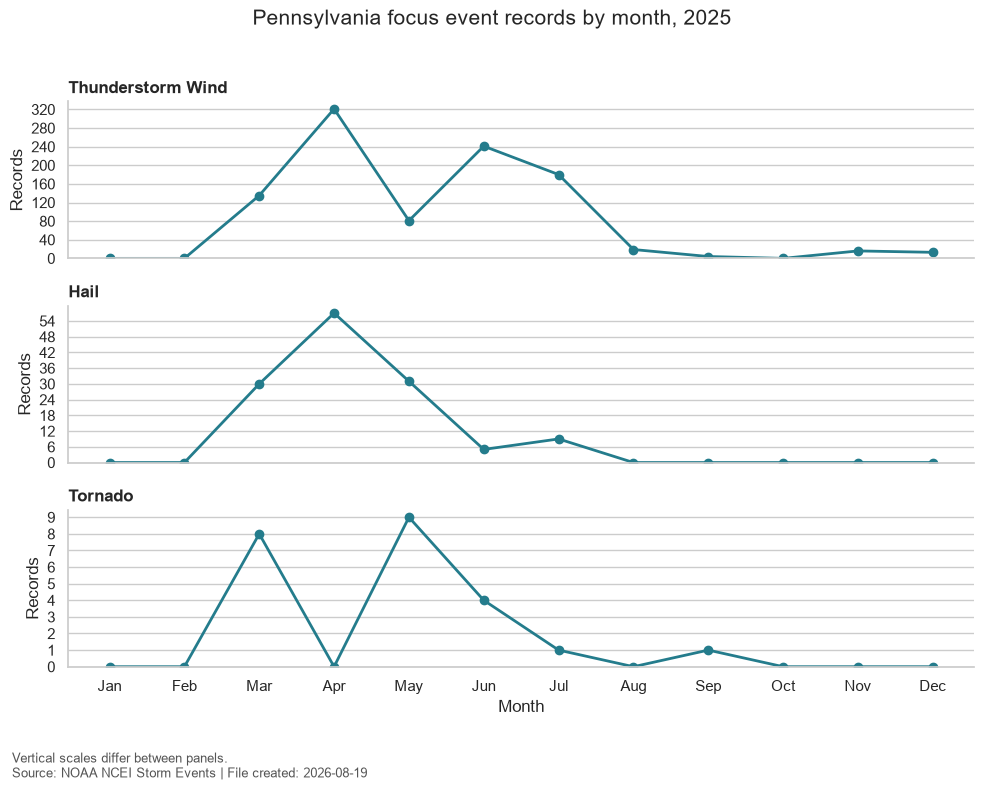

Saved chart: c:\Users\rcolo\OneDrive\Desktop\Pennsylvania-Severe-Weather-Atlas\reports\figures\pa_monthly_focus_events_2025.png


In [11]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

for ax, event_type in zip(axes, FOCUS_EVENT_TYPES):
    ax.plot(
        monthly_focus_counts.index,
        monthly_focus_counts[event_type],
        marker="o",
        linewidth=2,
        color="#247C8C",
    )
    ax.set_title(event_type, loc="left", fontweight="bold")
    ax.set_ylabel("Records")
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_locator(
        matplotlib.ticker.MaxNLocator(integer=True)
    )
    ax.grid(axis="x", visible=False)
    sns.despine(ax=ax)

axes[-1].set_xlabel("Month")

fig.suptitle(
    f"Pennsylvania focus event records by month, {AUDIT_YEAR}",
    fontsize=15,
)

fig.text(
    0.02,
    0.02,
    "Vertical scales differ between panels.\n"
    f"Source: NOAA NCEI Storm Events | File created: {audit_file['file_created']:%Y-%m-%d}",
    fontsize=9,
    color="#555555",
)
fig.tight_layout(rect=[0, 0.075, 1, 0.96])

monthly_chart_path = (
    PROJECT_PATHS["figures"] / f"pa_monthly_focus_events_{AUDIT_YEAR}.png"
)
fig.savefig(monthly_chart_path, dpi=200, bbox_inches="tight")

plt.show()
print("Saved chart:", monthly_chart_path)

### Monthly charts — results

The panels show different monthly patterns across the three categories:

- Thunderstorm Wind peaks in April with 321 records, followed by June with 241.
- Hail peaks in April with 57 records.
- Tornado peaks in May with 9 records, followed by March with 8.

The separate vertical scales make each category's monthly pattern visible. Comparisons of record counts across panels must use the labeled values.

These findings describe the selected Pennsylvania records for 2025.

## Saving the initial audit outputs

We will save the file inventory, category counts, monthly counts, and filtered 2025 dataset.

We will also update the source registry to indicate that the 2025 sample has been inspected, while the full study-period audit remains pending.

Each CSV will be reopened to check its row count and column names.

For the monthly table, `reset_index()` turns the month labels into a column so they are preserved when saving with `index=False`.

In [12]:
source_registry.loc[
    source_registry["source_id"].eq("noaa_storm_events"),
    "status",
] = f"{AUDIT_YEAR} sample inspected; full audit pending"

audit_exports = {
    PROJECT_PATHS["tables"] / "noaa_details_file_inventory.csv":
        file_inventory,
    PROJECT_PATHS["tables"] / f"pa_focus_event_counts_{AUDIT_YEAR}.csv":
        focus_type_counts,
    PROJECT_PATHS["tables"] / f"pa_monthly_focus_counts_{AUDIT_YEAR}.csv":
        monthly_focus_counts.reset_index(),
    PROJECT_PATHS["processed"] / f"pa_focus_events_{AUDIT_YEAR}_audit.csv":
        pa_focus_audit,
    registry_path:
        source_registry,
}

export_checks = []

for output_path, table in audit_exports.items():
    table.to_csv(output_path, index=False)
    reopened = pd.read_csv(output_path, low_memory=False)

    export_checks.append({
        "file": output_path.name,
        "saved_rows": len(reopened),
        "rows_match": len(reopened) == len(table),
        "columns_match": reopened.columns.tolist() == table.columns.tolist(),
    })

pd.DataFrame(export_checks)

,file,saved_rows,rows_match,columns_match
0,noaa_details_file_inventory.csv,77,True,True
1,pa_focus_event_counts_2025.csv,3,True,True
2,pa_monthly_focus_counts_2025.csv,12,True,True
3,pa_focus_events_2025_audit.csv,1165,True,True
4,data_source_registry.csv,1,True,True


## Export verification — results

All five CSV files were saved and reopened successfully. Every file matched its source DataFrame's row count and column names.

| File | Saved rows |
|---|---:|
| noaa_details_file_inventory.csv | 77 |
| pa_focus_event_counts_2025.csv | 3 |
| pa_monthly_focus_counts_2025.csv | 12 |
| pa_focus_events_2025_audit.csv | 1,165 |
| data_source_registry.csv | 1 |

## Notebook 1 — conclusion

We established the project environment, verified project paths, registered the NOAA source, and inspected an initial annual dataset.

The 2025 file contains 72,360 records, including 2,249 Pennsylvania records. Our three focus categories contain 1,165 records:
- Thunderstorm Wind: 1,010
- Hail: 132
- Tornado: 23

Within this subset, event IDs are complete and unique. All start dates parsed successfully and fall within 2025. Monthly counts reconcile to the subset total.

We produced two figures showing category totals and monthly patterns. April has the highest combined count, while tornado records peak in May.

This completes the initial 2025 inspection. The source registry records that the broader audit remains pending.

## Next step

Define the full study period and Lehigh Valley geographic scope, review historical reporting differences, and prepare the multi-year dataset.